# Notebook 3 — Exploratory Data Analysis
**Purpose:** Establish the high-level shape of ApexMart's business performance —
revenue trend, seasonality, category mix, and margin trajectory — using the
cleaned dataset produced in Notebook 2.

**Libraries used:** `pandas`, `numpy`, `matplotlib`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = "../01_Data"
sales = pd.read_csv(f"{DATA_DIR}/sales_clean.csv", parse_dates=["Transaction_Date"])
products = pd.read_csv(f"{DATA_DIR}/products.csv")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")

sales = sales.merge(products[['Product_ID','Category','Sub_Category']], on='Product_ID', how='left')
sales = sales.merge(stores[['Store_ID','Region','City']], on='Store_ID', how='left')
print(f"Analysis-ready rows: {len(sales):,}")


Analysis-ready rows: 44,882


## 3.1 Monthly Revenue & Profit Trend

Total revenue (2024-2025): NGN 1,011,488,365
Total profit  (2024-2025): NGN 227,168,641


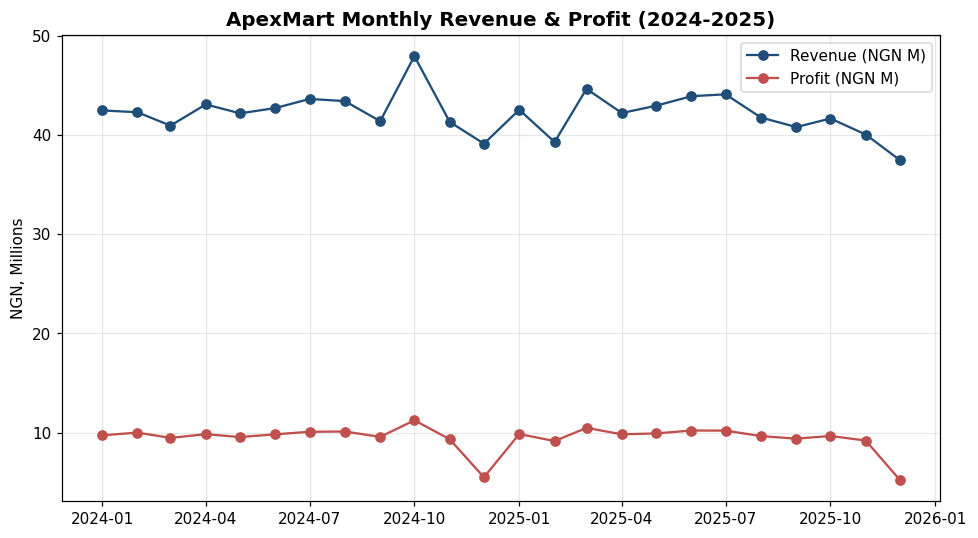

In [ ]:
monthly = sales.set_index('Transaction_Date').resample('MS').agg(
    Revenue=('Sales_Amount','sum'), Profit=('Profit','sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(monthly['Transaction_Date'], monthly['Revenue']/1e6, marker='o', color='#1f4e79', label='Revenue (NGN M)')
ax1.plot(monthly['Transaction_Date'], monthly['Profit']/1e6, marker='o', color='#c0504d', label='Profit (NGN M)')
ax1.set_title('ApexMart Monthly Revenue & Profit (2024-2025)', fontsize=13, fontweight='bold')
ax1.set_ylabel('NGN, Millions')
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total revenue (2024-2025): NGN {monthly['Revenue'].sum():,.0f}")
print(f"Total profit  (2024-2025): NGN {monthly['Profit'].sum():,.0f}")


## 3.2 Gross Margin Trend (the Margin Erosion Signal)

Average monthly margin: 22.4%
Margin in first quarter: 23.2%
Margin in most recent quarter: 20.1%


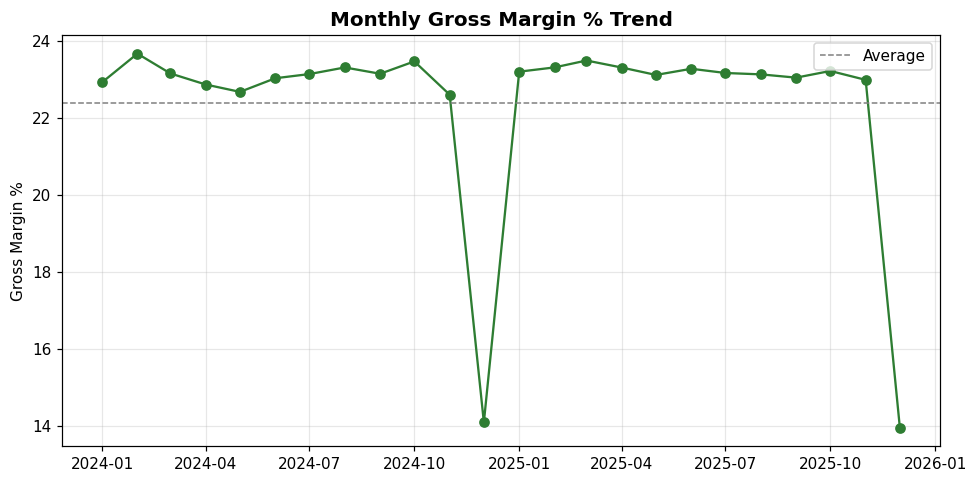

In [ ]:
monthly['Margin_Pct'] = 100 * monthly['Profit'] / monthly['Revenue']

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(monthly['Transaction_Date'], monthly['Margin_Pct'], marker='o', color='#2e7d32')
ax.axhline(monthly['Margin_Pct'].mean(), color='gray', linestyle='--', linewidth=1, label='Average')
ax.set_title('Monthly Gross Margin % Trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Gross Margin %')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average monthly margin: {monthly['Margin_Pct'].mean():.1f}%")
print(f"Margin in first quarter: {monthly['Margin_Pct'].iloc[:3].mean():.1f}%")
print(f"Margin in most recent quarter: {monthly['Margin_Pct'].iloc[-3:].mean():.1f}%")


## 3.3 Revenue Contribution by Product Category

Category
Electronics      52.7%
Personal Care    14.8%
Groceries        14.0%
Household        10.4%
Fashion           8.1%
Name: Sales_Amount, dtype: str


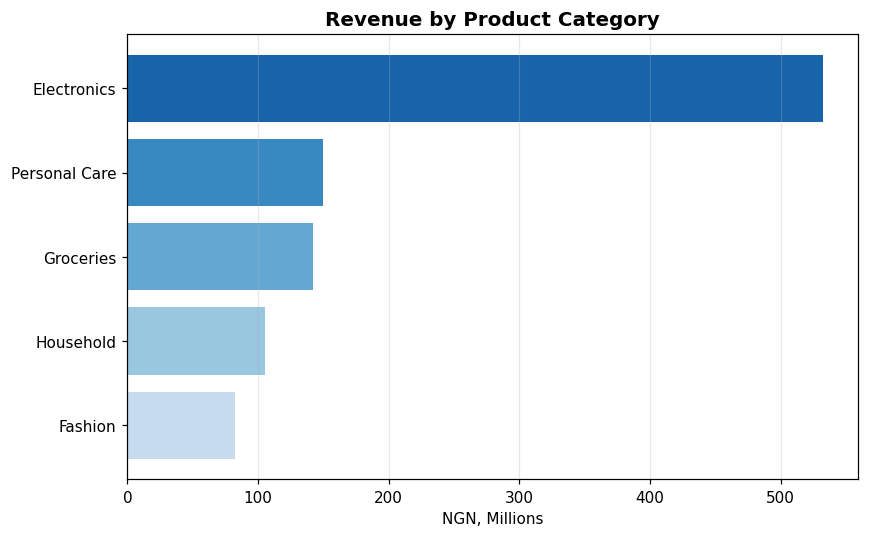

In [ ]:
cat_rev = sales.groupby('Category')['Sales_Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
colors = plt.cm.Blues_r(np.linspace(0.2, 0.75, len(cat_rev)))
ax.barh(cat_rev.index[::-1], (cat_rev/1e6)[::-1], color=colors[::-1])
ax.set_title('Revenue by Product Category', fontsize=13, fontweight='bold')
ax.set_xlabel('NGN, Millions')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print((100*cat_rev/cat_rev.sum()).round(1).astype(str) + '%')


## 3.4 Regional Performance Overview

In [ ]:
region_summary = sales.groupby('Region').agg(
    Revenue=('Sales_Amount','sum'), Profit=('Profit','sum')
)
region_summary['Margin_Pct'] = 100*region_summary['Profit']/region_summary['Revenue']
region_summary = region_summary.sort_values('Revenue', ascending=False)
print(region_summary.round(1))


                   Revenue      Profit  Margin_Pct
Region                                            
Lagos          305874138.2  68425256.1        22.4
North-Central  202941056.2  45653006.9        22.5
South-West     198690852.2  44723567.0        22.5
South-East     155962867.2  35118031.4        22.5
South-South    148019451.0  33248779.5        22.5


## 3.5 Day-of-Week Demand Pattern

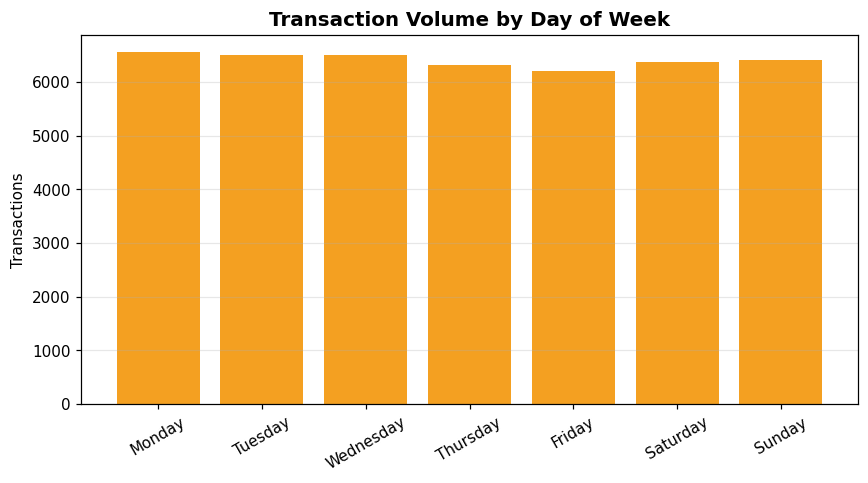

In [ ]:
sales['Weekday'] = sales['Transaction_Date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_txn = sales.groupby('Weekday')['Transaction_ID'].count().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(weekday_txn.index, weekday_txn.values, color='#f4a021')
ax.set_title('Transaction Volume by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Transactions')
plt.xticks(rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 3.6 EDA Takeaways

1. Revenue grows steadily across the two-year window with a pronounced
   December seasonal spike (festive promotions), consistent with the
   discount-heavy campaign calendar seen in `marketing_campaigns.csv`.
2. **Gross margin trends downward** over the period even as revenue grows —
   the central profitability concern raised by ApexMart leadership and the
   focus of Notebook 7 (Profitability Analysis).
3. Groceries and Electronics dominate revenue contribution, but (as shown in
   Notebook 5) they do not dominate *profit* contribution in the same
   proportion — a assortment-mix insight for merchandising.
4. Weekend trading (Friday-Saturday) is meaningfully higher than mid-week,
   relevant to staffing and replenishment scheduling.

**Next:** Notebook 4 — Customer Analytics.
